# Exploration of R3D data computed with full polarisation matrices in kappa

## Extra codes

### Create gas-kappa-file with empty scatmat-matrix

In [ ]:
# Write empty kappascatmat-file for usage for gas
# or other medium with no scattering.

import analyze_polarization_functions as apf
apf.write_r3d_emptypolarization()


### Remove spikes from images

In [ ]:
# TODO
# fix this code







# Remove spikes from Images
import numpy as np
import os
import re



models = [
    '../r3dresults_polarized_flashim/st28gm06n052_images',
    #'../r3dresults_polarized_flashim/st28gm06n074_images',
    #'../r3dresults_polarized_flashim/st28gm06n075_images',
]
# Loop over models
for model in models:
    print(
        f'Doing {model}'
    )
    # Extract all included snapshot numbers
    phases = [int(filename) for filename in os.listdir(f'{model}_1/') if os.path.isdir(f'{model}_1/{filename}')]
    phases.sort()
    for phase in phases:    
        print(
            f'  snapshot {phase:03d}'
        )
        # Extract all included images
        imagefiles = []
        for filename in os.listdir(f'{model}_1/{phase}/'):
            if filename.split('_')[0] == 'image':
                #
                folders = [
                    f'{model}_1/{phase:03d}/',
                    f'{model}_2/{phase:03d}/',
                    f'{model}_3/{phase:03d}/',
                ]
                # Number of images to combine
                Nimage = len(folders)
                # Delcare Lists
                allimages_i = []
                allimages_q = []
                allimages_u = []
                allimages_v = []
                npix = []
                header = []
                # Load images and put in list
                for nfolder,folder in enumerate(folders):
                    # Create image pixel flux lists
                    # Polarization column order: i, q, u, v
                    image_i = []
                    image_q = []
                    image_u = []
                    image_v = []
                    # Load imagefile
                    # line 1 is: npix-x    npix-y
                    # line >5 are pixel fluxes
                    with open(folder+filename,'r') as imagefile:
                        for nline,line in enumerate(imagefile.readlines()):
                            
                            # Save header lines
                            if nline < 6 and nfolder == 0:
                                header.append(line)

                            # Extract resolution
                            if nline == 1:
                                npix.append(int(re.findall('\d+', line)[0]))

                            # Extract fluxes
                            if nline > 5:
                                if len(line.split()) > 1:
                                    image_i.append(
                                        float(line.split()[0].strip())
                                    )
                                    image_q.append(
                                        float(line.split()[1].strip())
                                    )
                                    image_u.append(
                                        float(line.split()[2].strip())
                                    )
                                    image_v.append(
                                        float(line.split()[3].strip())
                                    )
                            else:
                                raise ValueError(
                                    'Not polarized!'
                                )
                    # Save each image as lilsts in one list
                    allimages_i.append(image_i)
                    allimages_q.append(image_q)
                    allimages_u.append(image_u)
                    allimages_v.append(image_v)
                # Loop through all images simulatneously and save the minimum flux density of each
                # in an array

                # TODO här är jag

                # Remove spikes on images in folders
                #
                #   TODO
                #
                # funkar detta med polariserade bilder???
                # kan denna ta hänsyn till alla varianter?
                #



    # Loop through all images simulatneously and save the minimum flux density of each
    # in an array
    newimagefluxes = np.zeros(npix[0]**2)

    for nn in range(npix[0]**2):

        # Reset list for pixelwise flux density of each image
        comparefluxes = []

        for nimage in range(Nimage):
            comparefluxes.append(images[nimage][nn])
        
        # Save minimum flux density of each image pixel
        newimagefluxes[nn] = np.min(comparefluxes)


    # Save new image
    with open(f'../{imagefilename}', 'w') as fnewimage:
        
        # First write copy of header
        for line in header:
            fnewimage.writelines(line)

        # Then write fluxes
        for newflux in newimagefluxes:
            fnewimage.writelines(f'   {newflux}\n')

    # Return image1D, np-array with flux densities in cgs-units at 1pc
    return newimagefluxes






                if os.path.exists(f'{model}_nospikes/{phase:03d}') == False:
                    os.system(f'mkdir {model}_nospikes/{phase:03d}')
                os.system(f'mv ../{imagename} {model}_nospikes/{phase:03d}/')





os.system('spd-say moo')



Doing ../r3dresults_vltcompare/st28gm06n052
  snapshot 166
  snapshot 167
Doing ../r3dresults_vltcompare/st28gm06n074
  snapshot 110
  snapshot 111
Doing ../r3dresults_vltcompare/st28gm06n075
  snapshot 208
  snapshot 209


0

In [1]:
# Interpolate images for missing snapshots
# Interpolates all polarizations as well

# Define stuff
modelname = 'st28gm06n075'
phases = [
    144
]
imagewaves = [
    '0.65','0.82'
]
angles = [
    'i000_phi000',
    'i090_phi000',
    'i090_phi090',
    'i090_phi270',
    'i180_phi000',
    'i270_phi000',
]
# Loop through each phase and interpolate images and SEDs
for phase in phases:
    prev_phase = phase-1
    next_phase = phase+1
    # Loop through angles
    for angle in angles:
        # Fix images
        #
        # Load images and polarizations
        for imagewave in imagewaves:
            # Reset lists
            imageheader = []
            #
            prev_i = []
            prev_q = []
            prev_u = []
            prev_v = []
            #
            next_i = []
            next_q = []
            next_u = []
            next_v = []
            #
            with open(f'../r3dresults_polarized/{modelname}_images/{prev_phase:03d}/image_{angle}_{imagewave}um.out', 'r') as fprev_image:
                for nline,line in enumerate(fprev_image.readlines()):
                    # First save header
                    if nline < 6:
                        imageheader.append(line)
                    if nline >= 6:
                    # Then prev flux densities
                        imagedata = line.split()
                        #
                        if len(imagedata) == 4:
                            prev_i.append(float(imagedata[0]))
                            prev_q.append(float(imagedata[1]))
                            prev_u.append(float(imagedata[2]))
                            prev_v.append(float(imagedata[3]))
            #
            # And next image flux densities
            with open(f'../r3dresults_polarized/{modelname}_images/{next_phase:03d}/image_{angle}_{imagewave}um.out', 'r') as fnext_image:
                for nline,line in enumerate(fnext_image.readlines()):
                    if nline >= 6:
                        imagedata = line.split()
                        #
                        if len(imagedata) == 4:
                            next_i.append(float(imagedata[0]))
                            next_q.append(float(imagedata[1]))
                            next_u.append(float(imagedata[2]))
                            next_v.append(float(imagedata[3]))
            #
            # And save number of pixels
            Npixels = len(next_i)
            #
            # Write new image-files
            with open(f'../r3dresults_polarized/{modelname}_images/{phase:03d}/image_{angle}_{imagewave}um.out', 'w') as fimage:
                #
                # Write header
                for line in imageheader:
                    fimage.write(f'{line}')
                #
                # Write image fluxes and polarizations
                for npixel in range(Npixels):
                    fimage.write(
                        f' {0.5*(prev_i[npixel]+next_i[npixel])}  {0.5*(prev_q[npixel]+next_q[npixel])}  {0.5*(prev_u[npixel]+next_u[npixel])}  {0.5*(prev_v[npixel]+next_v[npixel])}\n'
                    )


## Test code for plotting each polarization component

See Radmc3d-manual for info on polarisation. 

> radmc3d image stokes

Gives image.out-files with 4 columns of pixel data, ie 4 images in each file in the following order:

- I : Total intensity. the incident light
- Q : describes linear polarisation (horizontal or vertical, depending on the sign).
- U : describes polarisation at a 2nd set of orthogonal axes (+/-45 degrees)
- V : describes elliptical polarisation (right-handed if > 0, left-handed < 0)

R3d uses IAU 1974 definition as described in Hamaker & Bregman (1996) A&AS 117, pp.161. (see manual sect 6.9.1 Definitions ...).

All polarised light combines into I via

> I^2 = Q^2 + U^2 + V^2

Only linear polarised light is defined as the complex statement

> L = Q + iU

so that the absolute is (ie the INTENSITY of the LINEAR polarised light)

> |L| = sqrt(Q^2 + U^2)

and the INTENSITY of the CIRCULAR polarised light is simply

> |V| = sqrt(V^2)


### Plot images of polarization intensities

All total fluxes - v:
                     4.390e+02 Jy
                     6.143e+00 Jy
                     7.428e+01 Jy
                     4.077e+01 Jy
                     2.487e+01 Jy
                     1.675e+01 Jy


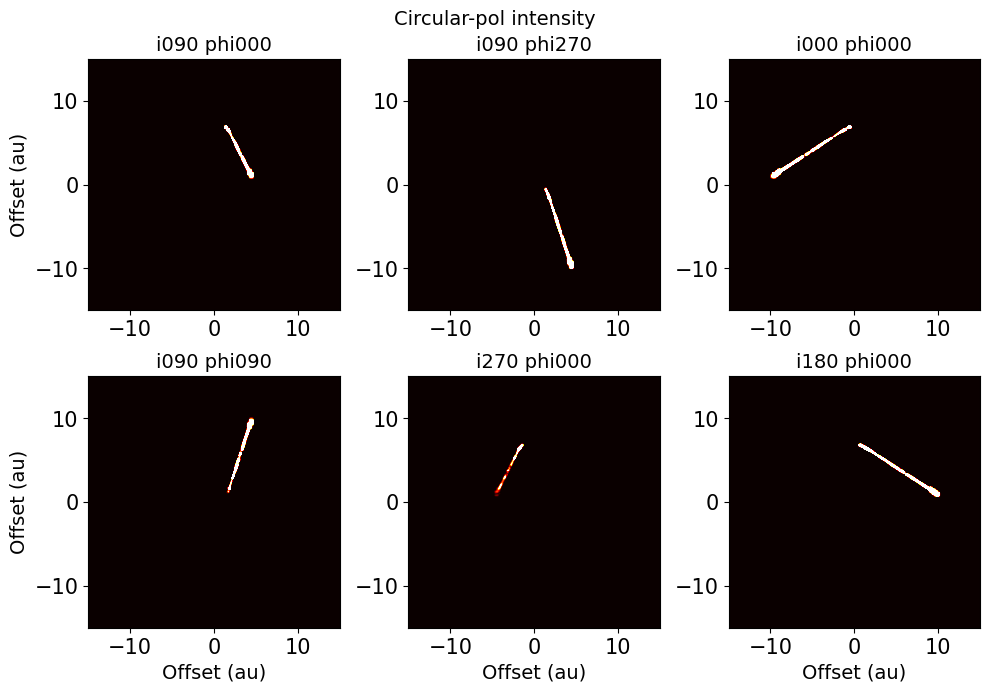

In [ ]:
# Plot all images of one polarization and at one snapshot
# and one wavelenght only
#
import analyze_polarization_functions as apf

"""
    > plotta L-intensity 0.65um bilder för snapshots
        052     116 143 169 222 279 299 314 318
        074     11  28  31  76  87 103 200 236 271 272 311 339 382 430
        075     87 123 135 167 186 190 204 208 219 303 361 395 422 424
    > Plott V-intesntiy bilder för snapshots
        052     169 222 299 314 318
        074     11  87 236 311 382
        075     190 303
""";

#for polarization in ['i','l','v']:
for polarization in ['v']:
    fig,ax,fluxtotal = apf.plot_intensity_onepolarization(
        imagepath='../r3dresults_polarized/st28gm06n075_images/303/',
        imagewave=0.65,
        polarization=polarization,
        vmaxcorr=1e-2
    )
    print(f'All total fluxes - {polarization}:')
    for flux in  fluxtotal:
        print(f'                     {flux:.3e} Jy')
    fig.set_figheight(7)
    fig.set_figwidth(10)
    fig.tight_layout()
    fig.subplots_adjust(top=0.92)
    #fig.show()


/tmp/ipykernel_43998/289907507.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


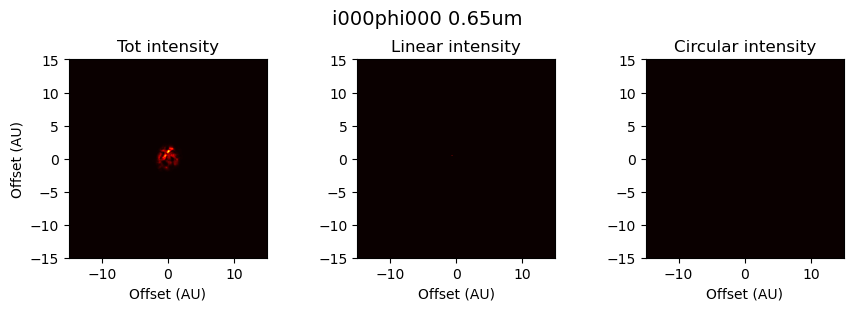

In [2]:
# Plot all polarizations of one angle
# one snapshot, one wavelength
# 
import analyze_polarization_functions as apf
fig,ax = apf.plot_intensity_allpolarizations(
    imagepath='../r3dresults_polarized/st28gm06n075_images/100/',
    imagefile='image_i000_phi000_0.65um.out',
    distance=1,
    vmaxcorr=1
)
fig.tight_layout()
fig.show()

qplus_max : 1.922e+00
qneg_max : -6.768e-85
uplus_max : 1.368e+00
uneg_max : -7.472e-85
vplus_max : 0.000e+00
vneg_max : 0.000e+00


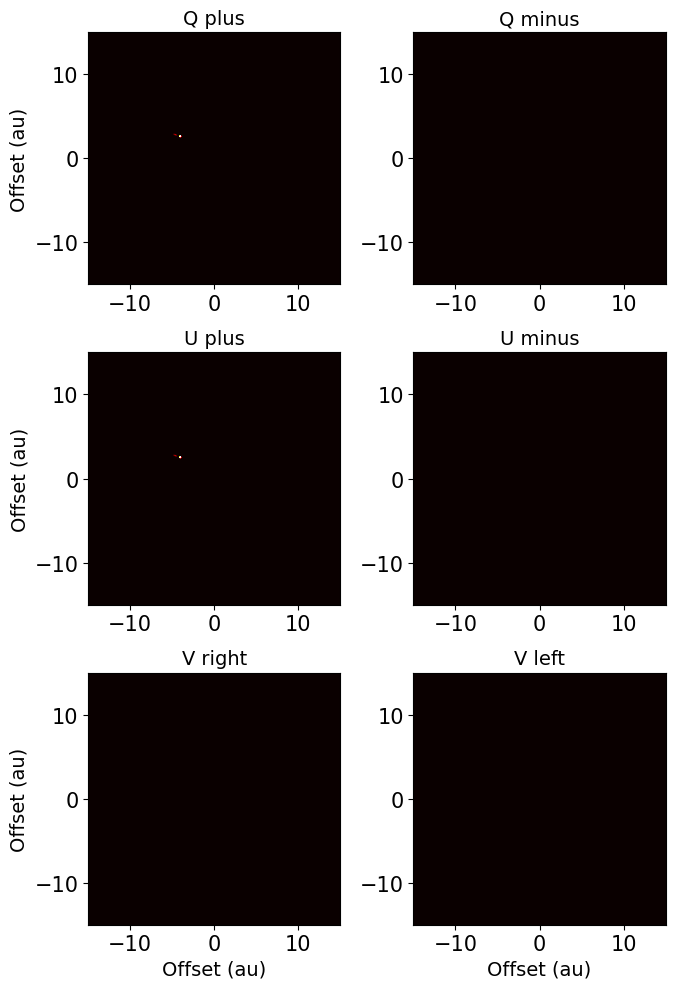

In [6]:
# Plot only strength of polarizations
import analyze_polarization_functions as apf

dict_polarizationmax,fig,ax = apf.plot_allpolarizationdirections(
    imagepath='../r3dresults_polarized/st28gm06n075_images/208/',
    imagefile='image_i000_phi000_0.65um.out',
    distance=1,
    vmaxcorr=1e-1,
)
fig.tight_layout()
for polmax in dict_polarizationmax:
    print(f'{polmax} : {dict_polarizationmax[polmax]:.3e}')


### Plot intensities over time

st28gm06n052
[143]
[143]
[143]
[143]
[143]
[169]
st28gm06n074
[28]
[28]
[339]
[28]
[28]
[28]
st28gm06n075
[123]
[123]
[123]
[123]
[123]
[123]


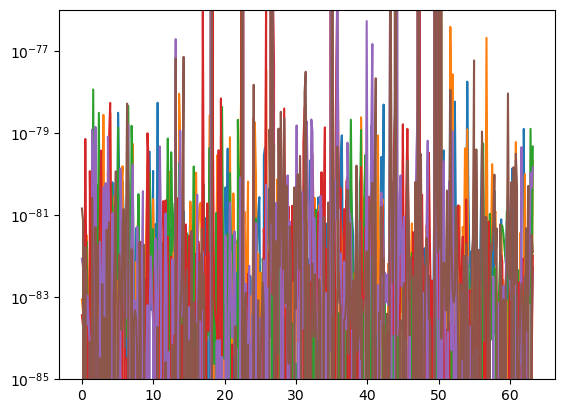

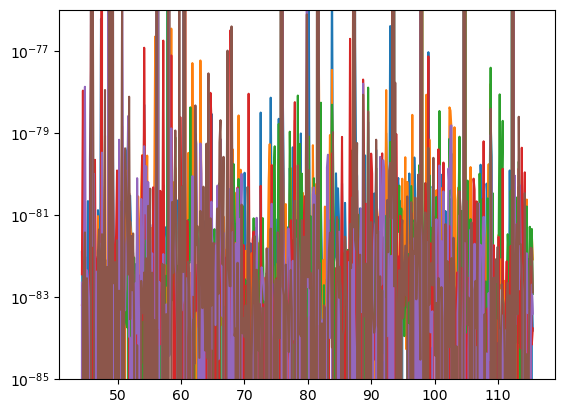

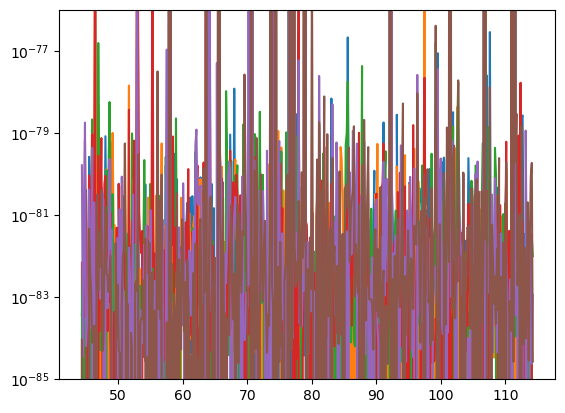

In [53]:
# Load and plot time-dependent Linear polarization intensities

import analyze_polarization_functions as apf
import numpy as np
import matplotlib.pyplot as plt


models = [
    'st28gm06n052',
    'st28gm06n074',
    'st28gm06n075',
]
ntop_indeces = [
    1,1,1
#    8,13,13   # for 0.65
#    14,25,31 # for 0.82
]
wavelength = '0.65'

for model,ntop_index in zip(models,ntop_indeces):
    print(
        model
    )
    snapshots, q_intensity, u_intensity, v_intensity, l_intensity = apf.load_polarizationintensities(
        file_path=f'../r3dresults_polarized/{model}_images/polarizationintensity_{wavelength}um.dat',
        angles=[
            'i000_phi000',
            'i090_phi000',
            'i090_phi090',
            'i090_phi270',
            'i180_phi000',
            'i270_phi000',
        ],
    )
    Nangles = len(
        l_intensity[0,:]
    )
    # Load time-dependence
    snap_times = np.loadtxt(
        f'../r3dresults_polarized/{model}_images/snapshot_yr.dat',
    )
    if len(snap_times[:,0]) != len(snapshots):
        raise ValueError(
            'Number of snapshots not equal to total time length'
        )
    # Plot L-intensity for all angles
    for nangle in range(Nangles):
        plt.figure(model)
        plt.plot(
            snap_times[:,1],
            l_intensity[:,nangle]
        )
        plt.yscale('log')
        #plt.ylim(1e-10,1e1)
        plt.ylim(1e-85,1e-76)
        # Print peak indices
        topindices = np.argpartition(l_intensity[:,nangle],-1*ntop_index)[-1*ntop_index:]
        print(np.sort(topindices)+1)



st28gm06n052
[169 222 299 314 318]
[169 222 299 314 318]
[169 222 299 314 318]
[169 222 299 314 318]
[169 222 299 314 318]
[169 222 299 314 318]
st28gm06n074
[ 11  87 236 311 382]
[ 87 150 236 311 382]
[ 11  87 236 311 382]
[ 11  87 236 311 382]
[ 11  87 236 311 382]
[ 11  87 236 311 382]
st28gm06n075
[190 303]
[190 303]
[190 303]
[190 303]
[190 303]
[190 303]


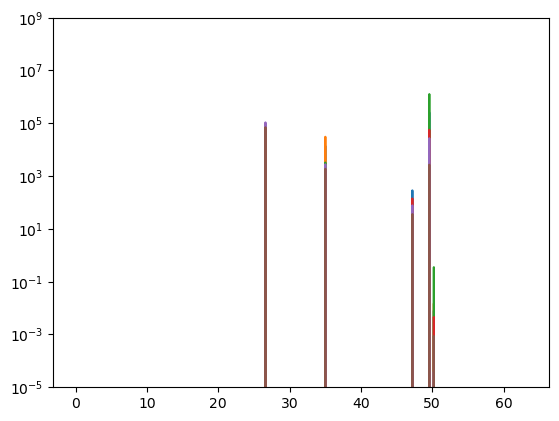

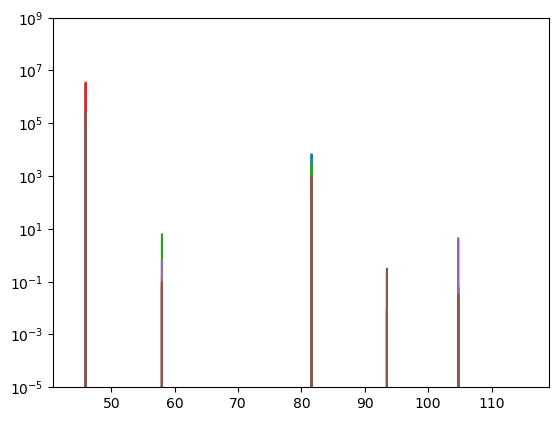

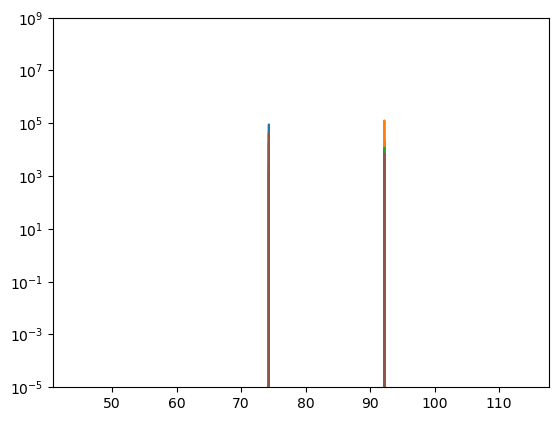

In [ ]:
# Load and plot time-dependent Circular polarization intensities

import analyze_polarization_functions as apf
import numpy as np
import matplotlib.pyplot as plt


models = [
    'st28gm06n052',
    'st28gm06n074',
    'st28gm06n075',
]
ntop_indeces = [
#    5,5,2   # for 0.65
    7,7,4   # for 0.82
]
wavelength = '0.82'

for model,ntop_index in zip(models,ntop_indeces):
    print(
        model
    )
    snapshots, q_intensity, u_intensity, v_intensity, l_intensity = apf.load_polarizationintensities(
        file_path=f'../r3dresults_polarized/{model}_images/polarizationintensity_{wavelength}um.dat',
        angles=[
            'i000_phi000',
            'i090_phi000',
            'i090_phi090',
            'i090_phi270',
            'i180_phi000',
            'i270_phi000',
        ],
    )
    Nangles = len(
        v_intensity[0,:]
    )
    # Load time-dependence
    snap_times = np.loadtxt(
        f'../r3dresults/{model}_nospikes/snapshot_yr.dat',
    )
    if len(snap_times[:,0]) != len(snapshots):
        raise ValueError(
            'Number of snapshots not equal to total time length'
        )
    # Plot L-intensity for all angles
    for nangle in range(Nangles):
        plt.figure(model)
        plt.plot(
            snap_times[:,1],
            v_intensity[:,nangle]
        )
        plt.yscale('log')
        plt.ylim(1e-5,1e9)
        # Print top 8 indices
        topindices = np.argpartition(v_intensity[:,nangle],-1*ntop_index)[-1*ntop_index:]
        print(np.sort(topindices)+1)

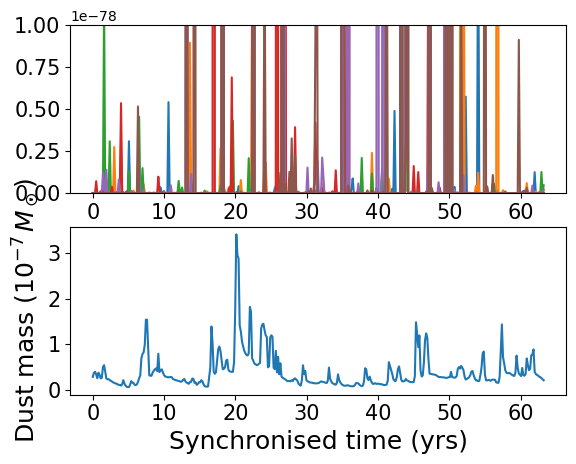

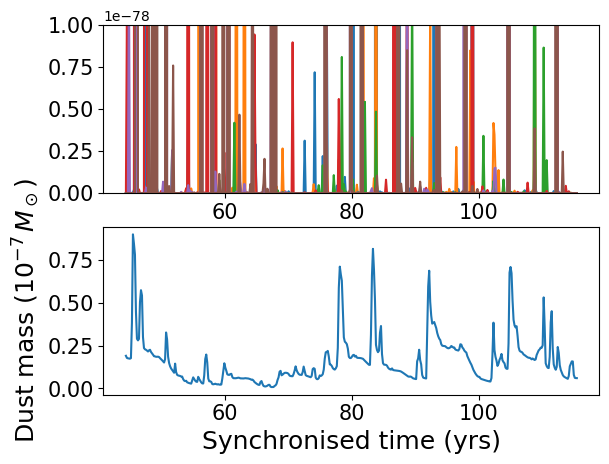

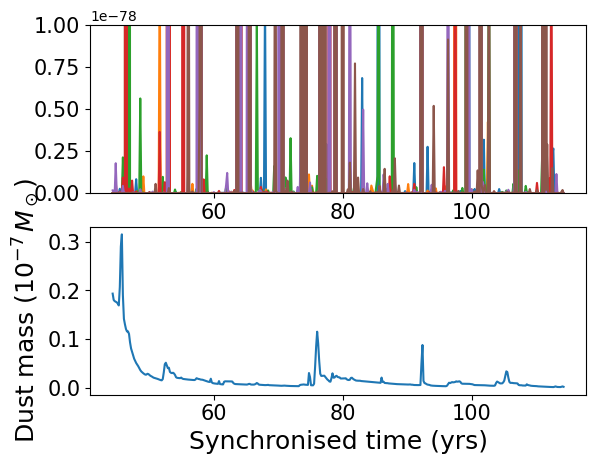

In [67]:
# Plot dustmass vs time and polarization vs time side by side


import analyze_polarization_functions as apf
import numpy as np
import matplotlib.pyplot as plt


models = [
    'st28gm06n052',
    'st28gm06n074',
    'st28gm06n075',
]
wavelength = '0.65'

for model in models:
    # Set up figure info
    fig,ax = plt.subplots(
        2,1, 
        num=model,
    )
    # Load polarization data
    snapshots, q_intensity, u_intensity, v_intensity, l_intensity = apf.load_polarizationintensities(
        file_path=f'../r3dresults_polarized/{model}_images/polarizationintensity_{wavelength}um.dat',
        angles=[
            'i000_phi000',
            'i090_phi000',
            'i090_phi090',
            'i090_phi270',
            'i180_phi000',
            'i270_phi000',
        ],
    )
    Nangles = len(
        l_intensity[0,:]
    )
    # Load time-dependence
    snap_times = np.loadtxt(
        f'../r3dresults_polarized/{model}_images/snapshot_yr.dat',
    )
    if len(snap_times[:,0]) != len(snapshots):
        raise ValueError(
            'Number of snapshots not equal to total time length'
        )
    # Plot L-intensity for all angles
    for nangle in range(Nangles):
        ax[0].plot(
            snap_times[:,1],
            l_intensity[:,nangle]
        )
    ax[0].set_ylim(0,1e-78)
    # Plot dust mass
    # Load dust mass data
    dustmass = np.loadtxt(f'../r3dresults/{model}_nospikes/dustmass.dat')[:,1]

    # Plot all dust masses on top of eachother
    massunit = 1e7
    ax[1].plot(
        snap_times[:,1],
        dustmass*massunit,
    )
    ax[1].set_ylabel(r'Dust mass ($10^{-7}\,M_\odot$)',fontsize=18)
    ax[1].set_xlabel('Synchronised time (yrs)',fontsize=18)
    ax[0].tick_params(axis='both', which='major', labelsize=15)
    ax[1].tick_params(axis='both', which='major', labelsize=15)


## Extract various useful values from polarized data


In [ ]:
# Extract all integrated polarization intensities
# and write to file
# Also saved in separate script: scriptpy_extractpolarizationintensity.py
import numpy as np
import os

models = [
    #'st28gm06n052',
    #'st28gm06n074',
    'st28gm06n075',
]
wavelengths = [
    '0.65',
    #'0.82',
]
distance = 1
angles = [
    'i000_phi000',
    'i090_phi000',
    'i090_phi090',
    'i090_phi270',
    'i180_phi000',
    'i270_phi000',
]
for wavelength in wavelengths:
    for model in models:

        modelpath = f'../r3dresults_polarized/{model}_images'
        modelname = model

        # Automatically add / to end of path if it's missing
        if modelpath[-1] != '/':
            modelpath += '/'

        # Extract all snapshot numbers for this model
        #snapshots = [int(filename) for filename in os.listdir(modelpath) if os.path.isdir(modelpath+filename)]
        #snapshots.sort()
        snapshots = [150,151]
        Nsnapshots = len(snapshots)

        # Open file to write all coords
        with open(f'{modelpath}polarizationintensity_{wavelength}um.dat','w') as fpol:
            print(
                f'  Writing polarization file\n    {modelpath}polarizationintensity_{wavelength}um.dat'
            )
            # Write header
            fpol.writelines(f'# Polarization intensity at lambda = {wavelength} um for {modelname}\n')
            fpol.writelines(f'Nsnapshots={Nsnapshots}\n')
            fpol.writelines(f'# Angles : \n')
            for angle in angles:
                fpol.writelines(f'    {angle}')
            fpol.writelines('\n# Snapshot      Q U V L for each angle in Jy at 1pc - 2 spaces between intensity and 4 spaces between angles.')
            #
            # Loop over time
            for snapshot in snapshots:
                # Print some output
                if snapshot == 100 or snapshot == 200 or snapshot == 300 or snapshot == 400:
                    print(f'  At snapshot {snapshot}')
                #
                # Print snapshot number to dat file
                fpol.writelines(f'\n{snapshot:03d}    ')
                #
                # Define image folder path
                imagepath = f'{modelpath}{snapshot}/'
                #
                # Loop over angles
                for angle in angles:
                    # Define image file name
                    image = f'image_{angle}_{wavelength}um.out'
                    # Define lists for polarization intensities
                    q_intensity = []
                    u_intensity = []
                    v_intensity = []
                    l_intensity = []
                    # Read image
                    with open(f'{imagepath}{image}', 'r') as fimage:
                        # Loop through image
                        for nl,line in enumerate(fimage.readlines()):
                            # Check if polarized image or not
                            if nl == 0:
                                imagesetting = int(
                                    line.strip()
                                )
                            # Then check polarisation setting
                            if imagesetting == 3:
                                # 3 means full polarisation, continue with extracting data
                                #
                                # row 6 onward: pixel-values, four columns
                                # image.out's pixels has unit
                                # erg s-1 cm-2 Hz-1 ster-1
                                if nl > 5:
                                    if len(line.split()) > 1:
                                        # Loop over polarisation numbers
                                        # Split line and extract each column, strip from \n and make floats
                                        # and change unit to Jy at chosen distance
                                        q_pixeldata = float(line.split()[1].strip()) * 1.e23 * 2.35044305391e-11 / distance**2
                                        u_pixeldata = float(line.split()[2].strip()) * 1.e23 * 2.35044305391e-11 / distance**2
                                        v_pixeldata = float(line.split()[3].strip()) * 1.e23 * 2.35044305391e-11 / distance**2
                                        #
                                        # Save intensities in lists
                                        #
                                        q_intensity.append(
                                            np.sqrt(q_pixeldata*q_pixeldata)
                                        )
                                        u_intensity.append(
                                            np.sqrt(u_pixeldata*u_pixeldata)
                                        )
                                        v_intensity.append(
                                            np.sqrt(v_pixeldata*v_pixeldata)
                                        )
                                        l_intensity.append(
                                            np.sqrt(q_pixeldata*q_pixeldata + u_pixeldata*u_pixeldata)
                                        )
                            else:
                                raise ValueError(
                                    'Not polarized image!'
                                )
                    # Extract total polarized intensity
                    q_total = np.sum(q_intensity)
                    u_total = np.sum(u_intensity)
                    v_total = np.sum(v_intensity)
                    l_total = np.sum(l_intensity)
                    #
                    # Print polarization intensities to file
                    fpol.writelines(
                        f'{q_total:.3e}  {u_total:.3e}  {v_total:.3e}  {l_total:.3e}    '
                    )

        # 8 snapshots: 1min
        # 7.125sek per snapshot
        # 400 tar 50min
        # 450 tar 55min
        # så 3h för 3 modeller 1 våglängd
        # 6h för allt



  Writing polarization file
    ../r3dresults_polarized/st28gm06n075_images/polarizationintensity_0.65um.dat


In [22]:
import numpy as np
import analyze_polarization_functions as apf
snapshots, q_intensity, u_intensity, v_intensity, l_intensity = apf.load_polarizationintensities(
    file_path='../r3dresults_polarized/st28gm06n052_images/polarizationintensity_0.65um.dat',
    angles=[
        #'i000_phi000',
        #'i090_phi000',
        'i090_phi090',
        #'i090_phi270',
        #'i180_phi000',
        #'i270_phi000',
    ],
)
#print(snapshots)
#print(q_intensity)
#print(u_intensity)
#print(v_intensity)
print(l_intensity)

[[0.000e+00]
 [0.000e+00]
 [0.000e+00]
 [2.964e-83]
 [2.290e-82]
 [1.030e-83]
 [6.755e-85]
 [4.725e-84]
 [1.221e-82]
 [6.535e-85]
 [1.139e-78]
 [1.389e-84]
 [3.432e-81]
 [5.312e-81]
 [3.104e-83]
 [3.085e-79]
 [3.439e-83]
 [5.704e-84]
 [2.234e-83]
 [2.424e-82]
 [0.000e+00]
 [4.489e-84]
 [0.000e+00]
 [0.000e+00]
 [1.560e-83]
 [4.298e-83]
 [5.472e-81]
 [5.051e-82]
 [2.437e-85]
 [1.689e-81]
 [7.869e-82]
 [2.757e-83]
 [1.323e-79]
 [1.938e-84]
 [1.249e-83]
 [2.508e-83]
 [1.011e-81]
 [3.060e-84]
 [2.807e-84]
 [1.079e-84]
 [4.830e-84]
 [4.548e-79]
 [1.262e-83]
 [3.909e-83]
 [1.488e-79]
 [6.933e-81]
 [1.912e-83]
 [0.000e+00]
 [4.224e-84]
 [0.000e+00]
 [3.223e-81]
 [8.617e-85]
 [7.431e-85]
 [9.562e-84]
 [4.034e-84]
 [2.112e-83]
 [7.754e-85]
 [3.646e-84]
 [3.933e-84]
 [9.808e-83]
 [1.079e-80]
 [1.724e-82]
 [9.832e-84]
 [4.538e-82]
 [0.000e+00]
 [2.966e-85]
 [1.696e-84]
 [3.345e-84]
 [6.491e-82]
 [3.930e-83]
 [5.873e-85]
 [0.000e+00]
 [2.208e-82]
 [0.000e+00]
 [6.137e-84]
 [2.052e-82]
 [7.263e-80]